# Biomedical CRP Analysis

Author: Manfred Anim

## Goal

Explore changes in C-reactive protein (CRP) from baseline to week 8 in a fictional dataset of 20 patients.

We will inspect missing values, compare CRP reductions between groups, and visualise individual changes and response rates.

This dataset is for learning purposes and does not represent clinical evidence.


In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
current_folder = Path.cwd()
print(current_folder)

C:\Users\kwaku\OneDrive\Dokumente\DBE\biomedical-data-analysis


In [4]:
project_folder = Path.cwd()
data_file = project_folder / "data" / "patient_data.csv"

patient_data = pd.read_csv(data_file)
patient_data.head()

,Patient_ID,Age,Sex,Treatment_Group,Baseline_CRP,Week8_CRP,Response
0,P001,34,F,Treatment,18.2,6.4,Yes
1,P002,51,M,Control,15.6,13.8,No
2,P003,42,F,Treatment,22.1,8.7,Yes
3,P004,63,M,Control,19.4,18.1,No
4,P005,29,F,Treatment,12.8,5.2,Yes


## Inspect the dataset

Check the number of patients and columns, and identify missing values before calculating results.

In [5]:
print(f"Patients: {patient_data.shape[0]}")
print(f"Columns: {patient_data.shape[1]}")

patient_data.isna().sum()


Patients: 20
Columns: 7


Patient_ID         0
Age                0
Sex                0
Treatment_Group    0
Baseline_CRP       0
Week8_CRP          1
Response           1
dtype: int64

## Calculate CRP reduction

CRP reduction is baseline CRP minus week-8 CRP. A positive value means CRP decreased.

Patients without both measurements are excluded from this calculation.

In [6]:
complete_data = patient_data.dropna(
    subset=["Baseline_CRP", "Week8_CRP"]
).copy()

complete_data["CRP_Reduction"] = (
    complete_data["Baseline_CRP"] - complete_data["Week8_CRP"]
)

group_summary = (
    complete_data.groupby("Treatment_Group")["CRP_Reduction"]
    .agg(["count", "mean", "median"])
    .round(2)
)

group_summary

,count,mean,median
Treatment_Group,,,
Control,10,1.63,1.65
Treatment,9,11.34,11.80


## Compare CRP reductions

The box plots summarise CRP reduction in each group. Each black point represents one patient with complete measurements.

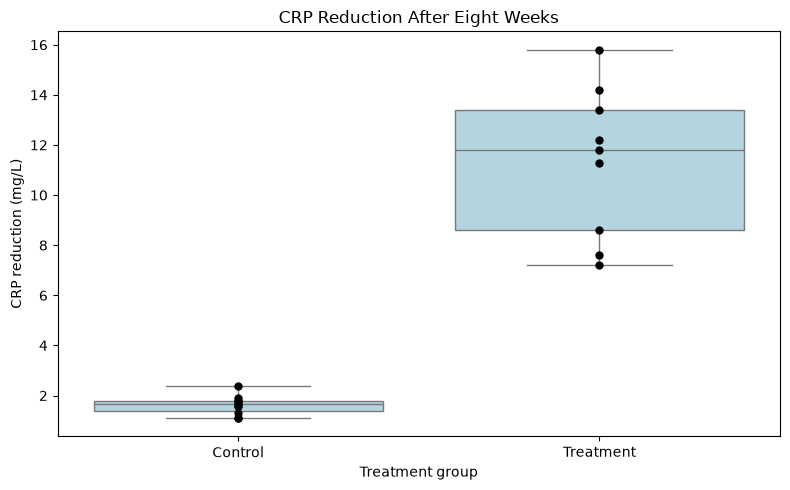

In [7]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=complete_data,
    x="Treatment_Group",
    y="CRP_Reduction",
    order=["Control", "Treatment"],
    color="lightblue"
)

sns.stripplot(
    data=complete_data,
    x="Treatment_Group",
    y="CRP_Reduction",
    order=["Control", "Treatment"],
    color="black",
    size=6,
    jitter=False
)

plt.title("CRP Reduction After Eight Weeks")
plt.xlabel("Treatment group")
plt.ylabel("CRP reduction (mg/L)")
plt.tight_layout()
plt.show()

## Individual CRP changes

Each line connects one patient's baseline and week-8 CRP measurements. A downward line indicates a decrease in CRP.

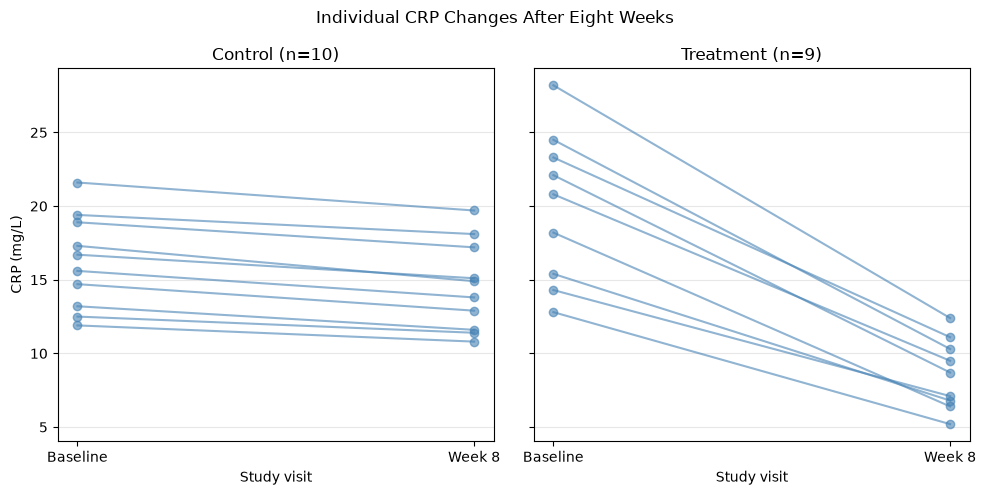

In [8]:
fig, axes = plt.subplots(
    1, 2, figsize=(10, 5), sharey=True
)

for ax, group_name in zip(axes, ["Control", "Treatment"]):
    group_data = complete_data[
        complete_data["Treatment_Group"] == group_name
    ]

    for _, patient in group_data.iterrows():
        ax.plot(
            [0, 1],
            [patient["Baseline_CRP"], patient["Week8_CRP"]],
            marker="o",
            color="steelblue",
            alpha=0.6
        )

    ax.set_xticks([0, 1], ["Baseline", "Week 8"])
    ax.set_title(f"{group_name} (n={len(group_data)})")
    ax.set_xlabel("Study visit")
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("CRP (mg/L)")
fig.suptitle("Individual CRP Changes After Eight Weeks")
plt.tight_layout()
plt.show()

## Treatment response rates

Response rates use patients with recorded response information.
One missing response is excluded rather than counted as "No".

The response labels are fictional and supplied in the dataset.

In [10]:
response_data = patient_data.dropna(subset=["Response"]).copy()

response_data["Responder"] = response_data["Response"].map(
    {"Yes": 1, "No": 0}
)

response_summary = (
    response_data.groupby("Treatment_Group")["Responder"]
    .agg(Responders="sum", Patients="count")
)

response_summary["Response_Rate_Percent"] = (
    response_summary["Responders"]
    / response_summary["Patients"]
    * 100
)

response_summary

,Responders,Patients,Response_Rate_Percent
Treatment_Group,,,
Control,0,10,0.0
Treatment,9,9,100.0


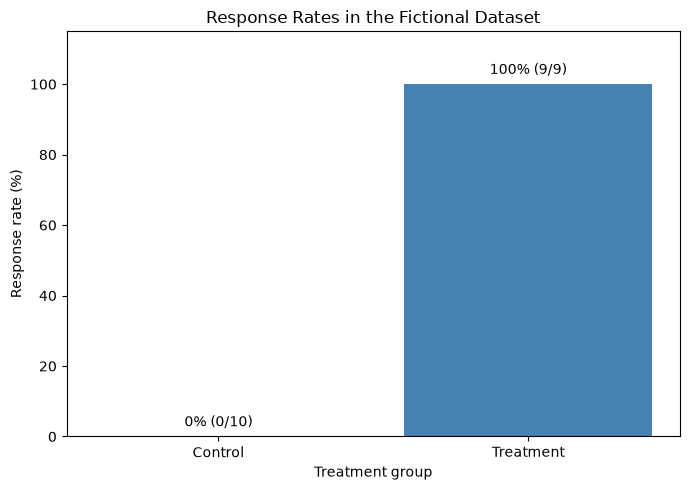

In [11]:
plot_data = response_summary.reindex(
    ["Control", "Treatment"]
)

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    plot_data.index,
    plot_data["Response_Rate_Percent"],
    color="steelblue"
)

labels = [
    f"{row['Response_Rate_Percent']:.0f}% "
    f"({int(row['Responders'])}/{int(row['Patients'])})"
    for _, row in plot_data.iterrows()
]

ax.bar_label(bars, labels=labels, padding=5)

ax.set_title("Response Rates in the Fictional Dataset")
ax.set_xlabel("Treatment group")
ax.set_ylabel("Response rate (%)")
ax.set_ylim(0, 115)

plt.tight_layout()
plt.show()

In [ ]:
## Takeaways

- The dataset contains 20 fictional patients.
- CRP-change analysis includes 19 patients with complete measurements.
- The treatment group shows larger CRP reductions than the control group.
- Recorded response rates are 9/9 for Treatment and 0/10 for Control.
- Missing measurements and responses were excluded from their respective analyses.

These results demonstrate Python analysis methods and do not provide clinical evidence.